In [13]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

In [3]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]


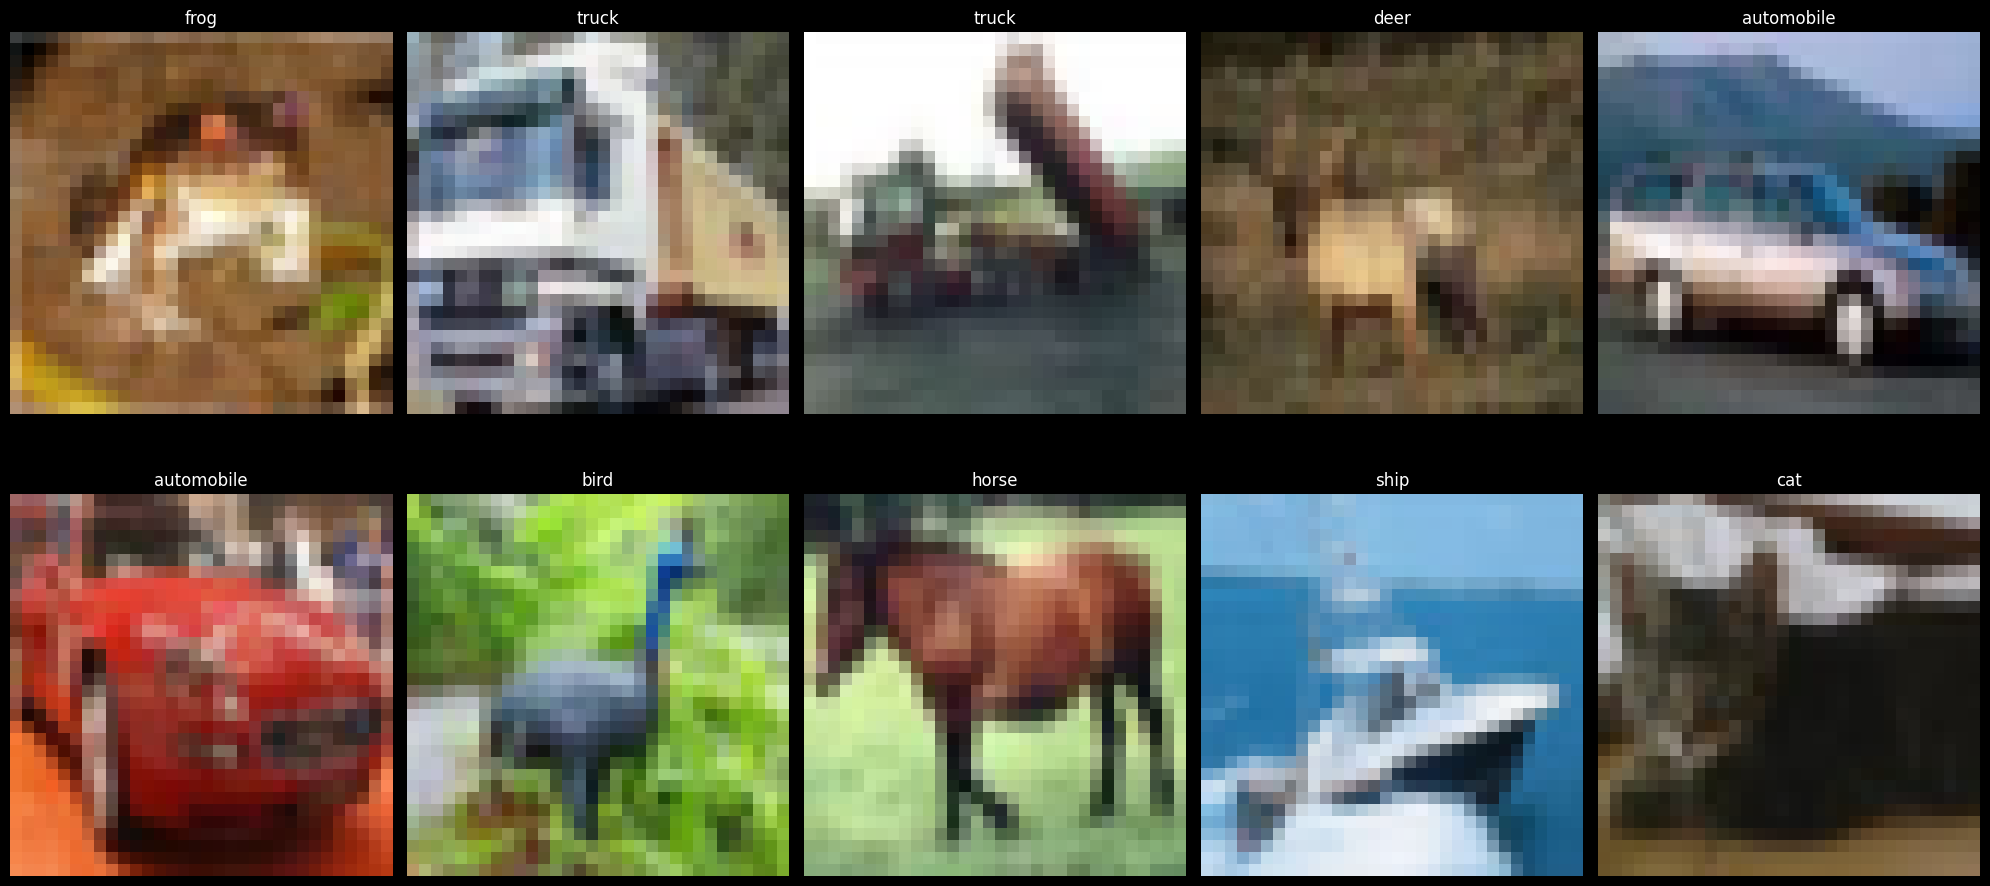

In [4]:
plt.figure(figsize=(20, 10))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])

    plt.title(str(classes[y_train[i][0]]))
    plt.axis("off")

plt.tight_layout()
plt.show()


In [5]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [6]:
y_train_ohe = tf.keras.utils.to_categorical(
    y_train, num_classes=len(np.unique(y_train))
)

y_test_ohe = tf.keras.utils.to_categorical(y_test, num_classes=len(np.unique(y_test)))

In [8]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=(X_train.shape[1], X_train.shape[2], X_train.shape[3])
        ),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(5000, activation="relu"),
        tf.keras.layers.Dense(1000, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ]
)

model.compile(optimizer="SGD", loss="categorical_crossentropy", metrics=["accuracy"])
model.fit(X_train_scaled, y_train_ohe, epochs=5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.3548 - loss: 1.8090
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.4293 - loss: 1.6172
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.4587 - loss: 1.5364
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.4801 - loss: 1.4790
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.5006 - loss: 1.4246


In [12]:
y_hat = model.predict(X_test_scaled)
y_hat_labels = [np.argmax(pred) for pred in y_hat]
y_hat_labels[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


[np.int64(3), np.int64(9), np.int64(0), np.int64(0), np.int64(4)]

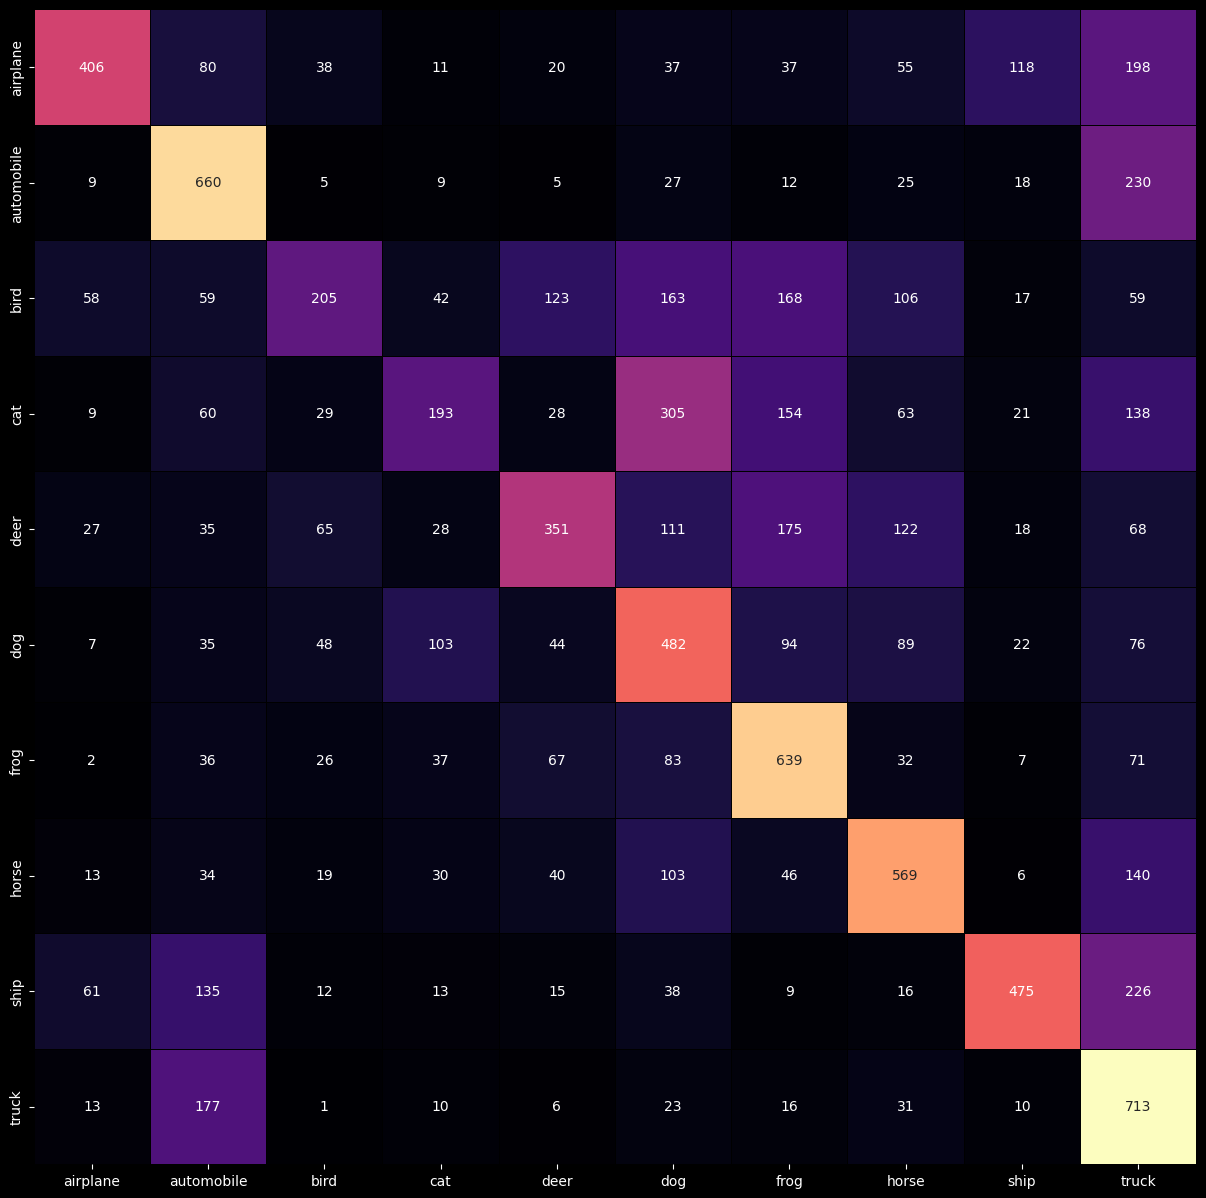

In [21]:
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_hat_labels)
plt.figure(figsize=(15, 15))
sns.heatmap(
    cm,
    cbar=False,
    annot=True,
    fmt="d",
    linecolor="black",
    linewidths=0.5,
    cmap="magma",
)
ax = plt.gca()
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
plt.show()